# Regimes and convergence — the per-regime metrics table

> **PROVISIONAL.** The regime *taxonomy* is ratified (2026-07-29, `docs/regime_taxonomy.md`):
> membership is assigned from a documented issuance rule, before any price is read. The
> **panel** is not ratified — the constrained class is four issuers under one regulator, and
> five of the six controls are Brazilian. Every number below inherits that.

**What this notebook is.** The S4 deliverable: out-of-fold RMSE, R² and sign hit rate for the
premium, per regime class and per horizon. It is the artifact that every trade sheet, hedge
ratio and convergence number in the project has been waiting on.

**What it is not.** There is no M2 regime classifier, and there does not need to be. The
regime label is read off a filing, so it is an **input** here. A model trained to predict a
label already fixed by a deposit agreement is fitted to its own answer key.

In [1]:
%matplotlib inline
import sys, pathlib
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
import pandas as pd
from pipeline.viz import theme, figures
from pipeline.convergence.jorda import (PANEL_CAVEATS, TAXONOMY_RATIFIED, TABLE_HORIZONS,
                                        run_panel, s4_metrics_table)
theme.apply()
print(f"taxonomy RATIFIED {TAXONOMY_RATIFIED}   horizons {TABLE_HORIZONS}")
for c in PANEL_CAVEATS: print("  PROVISIONAL:", c)

taxonomy RATIFIED 2026-07-29   horizons (1, 5, 20, 60)
  PROVISIONAL: constrained class is four issuers under ONE regulator -- reduces issuer noise, gives no independent variation in the rule
  PROVISIONAL: fungible class is five Brazilian pairs plus Alibaba -- one country dominates the control


## The table

Out-of-fold. Expanding walk-forward, 5 splits, **embargo = h** — training labels overlap the
test block by h periods, and without the embargo the fit sees its own test window through the
label. Centring fitted train-only. SKHY excluded from every fit.

The predictor is the Jordà local projection M3 already uses: π_{t+h} ~ π_t. **Sign hit rate
scores the change from today's level, not the level** — a premium that is almost always
positive would score ~100% on the level and tell you nothing.

In [2]:
tbl = s4_metrics_table()
tbl.drop(columns=["PROVISIONAL"])

,regime,horizon,n,rmse,r2,hit_rate
0,fungible,1,23254,0.021210,0.634388,0.571644
1,fungible,5,23236,0.036962,-0.109656,0.573679
2,fungible,20,23160,0.037790,-0.156573,0.590717
3,fungible,60,22960,0.037469,-0.128428,0.596559
4,one_way_constrained,1,13210,0.031950,0.917055,0.530883
5,one_way_constrained,5,13196,0.037356,0.886584,0.526069
6,one_way_constrained,20,13146,0.046219,0.826253,0.529439
7,one_way_constrained,60,13012,0.063146,0.676283,0.534122
8,POOLED (all classes),1,36464,0.025626,0.886619,0.556888
9,POOLED (all classes),5,36432,0.037105,0.762184,0.556434


**The classes separate out of sample, in the direction the mechanism predicts.** The
barrier-constrained premium is forecastable — R² 0.92 at h=1, still 0.68 at h=60. The fungible
control's R² is **negative beyond one day**: worse than predicting its own mean. There is no
persistence left in it, which is exactly what a working two-way arbitrage should leave behind.

**The hit rates run the other way, and that is worth saying out loud.** The control's sign hit
rate (57–60%) beats the constrained class's (53%). Level and direction are different
questions: the constrained premium's *level* is highly predictable while its next *move* is
close to a coin flip — the profile of a slow-moving series sitting near a barrier. A trade
sheet that quoted the R² and skipped the hit rate would be quoting the flattering half.

The pooled row is last and labelled. It is not a regime.

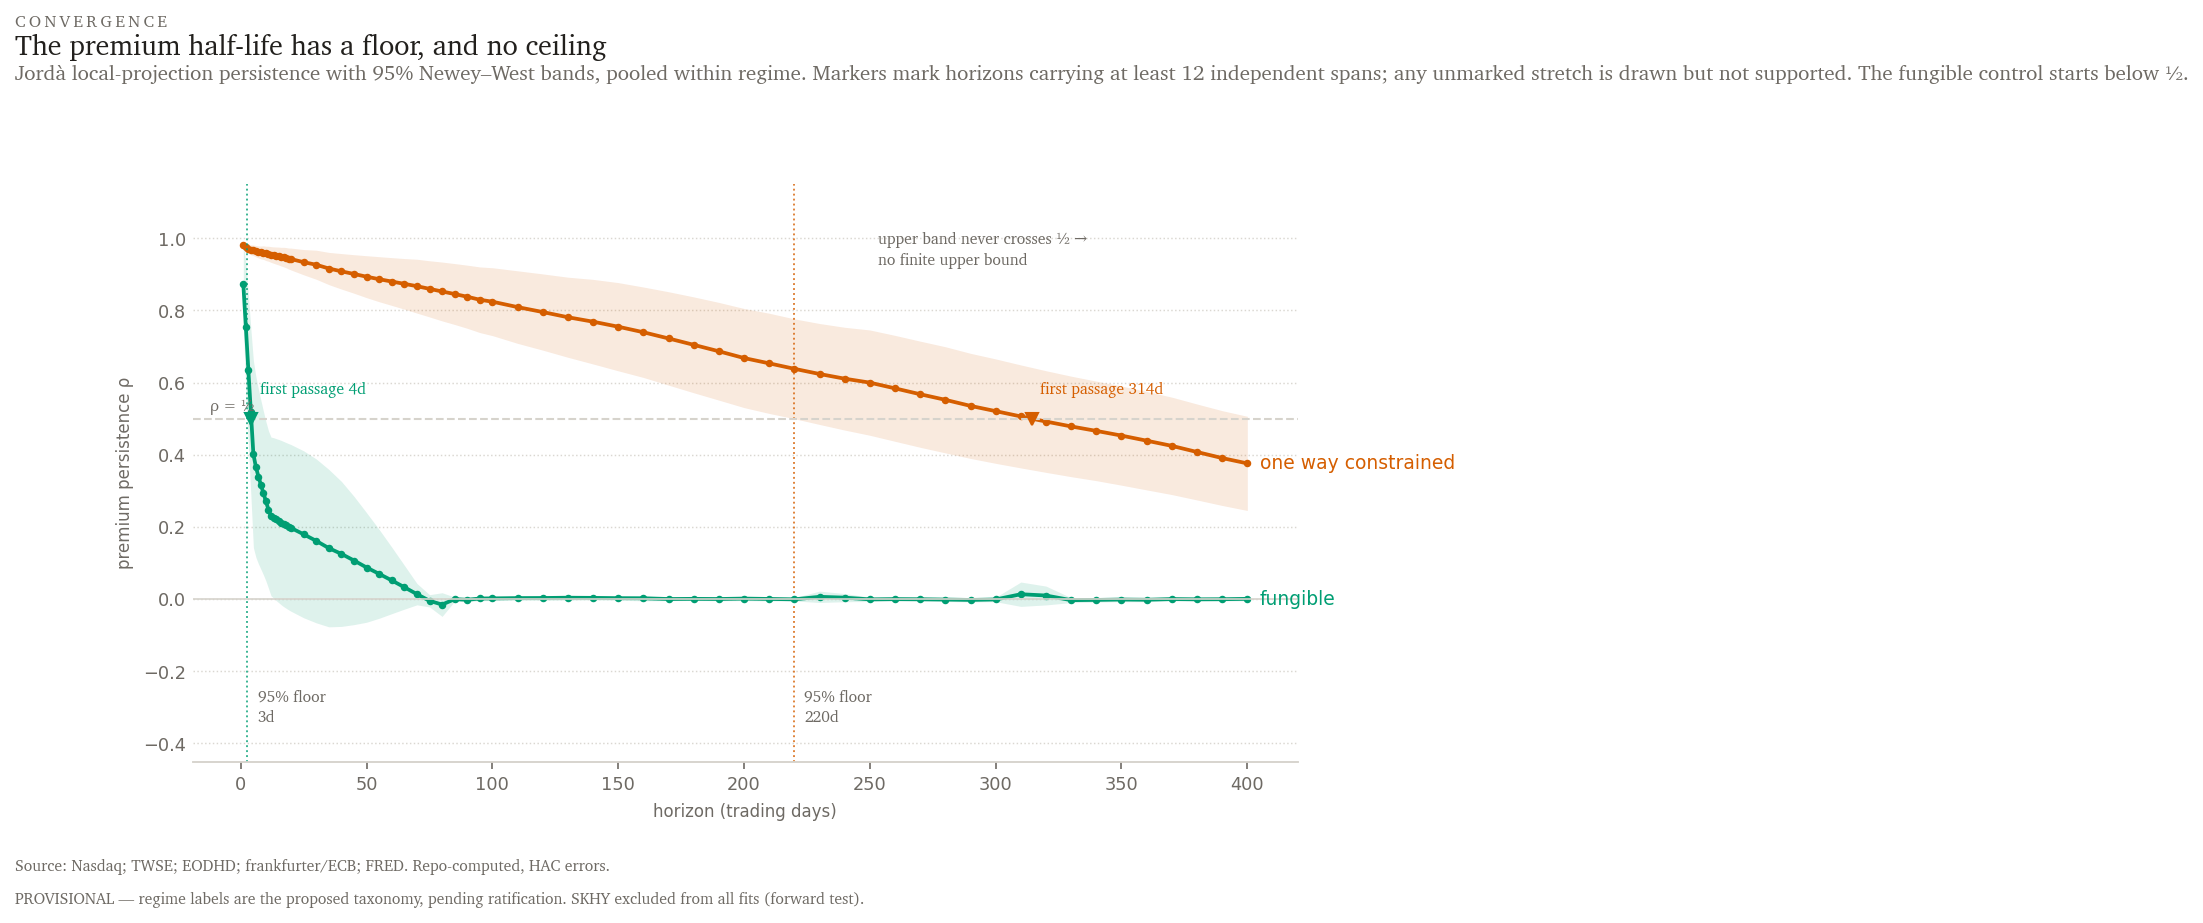

In [3]:
fig, ax = figures.g_convergence(run_panel())
fig;

**In plain terms**

- Gaps like this one close slowly. Ones where the trade works both ways close within days.
- Best case, on the evidence, is about ten and a half months. There is no worst case we can rule
  out — the data cannot say the gap ever halves.
- Anything you pay per day, you should assume you pay for at least ten months.

## Ablation — M6 is cut

One landed macro feature: each pair's **own** FX 20-day trend. In and out under identical
folds, which is asserted rather than assumed — the first version of this ablation dropped rows
when the feature was added, so the two arms scored different samples and RMSE appeared to
improve while R² fell. That is only possible when the sample moves underneath you.

In [4]:
base, macro = s4_metrics_table(), s4_metrics_table(with_macro=True)
j = base.merge(macro, on=["regime", "horizon"], suffixes=("_b", "_m"))
assert (j.n_b == j.n_m).all(), "ablation arms scored different samples"
j["d_rmse"] = j.rmse_m - j.rmse_b
j["d_r2"] = j.r2_m - j.r2_b
j["d_hit"] = j.hit_rate_m - j.hit_rate_b
print("identical folds CONFIRMED — n matches on every row\n")
j[["regime", "horizon", "n_b", "d_rmse", "d_r2", "d_hit"]].round(5)

identical folds CONFIRMED — n matches on every row



,regime,horizon,n_b,d_rmse,d_r2,d_hit
0,fungible,1,23254,0.00001,-0.00039,0.00529
1,fungible,5,23236,0.00009,-0.00539,0.00637
2,fungible,20,23160,0.00005,-0.00320,-0.00522
3,fungible,60,22960,0.00036,-0.02203,0.00775
4,one_way_constrained,1,13210,0.00005,-0.00028,0.00038
5,one_way_constrained,5,13196,0.00018,-0.00109,0.00167
6,one_way_constrained,20,13146,0.00040,-0.00304,0.00776
7,one_way_constrained,60,13012,0.00050,-0.00519,0.01506
8,POOLED (all classes),1,36464,0.00003,-0.00027,0.00351
9,POOLED (all classes),5,36432,0.00012,-0.00157,0.00467


**Verdict: cut.** RMSE worsens and R² falls at every horizon in every class. Hit rate moves up
marginally, not enough to offset either. A near-zero-to-negative delta cuts the family, and
**that is a finding, not a failure** — it says the premium's dynamics are its own rather than
an FX overlay, consistent with FX explaining ~1.2% of daily premium variance.

**Degenerate-regime check.** No degenerate case here: the feature hurts *both* classes, so the
pooled row is not concealing an offsetting split. Had the signs been opposite by class with a
negative pooled net, it would be stated here in those words rather than left for a reader to
reconstruct from the deltas.

M5 was not built. `docs/features_m5.md` gives the reason instead of a stub: the table needed no
features to exist, this ablation is the prior, and the strongest remaining candidate
(utilization states) is gated on unlanded D3.

## Variance shares — and why they do not separate the classes

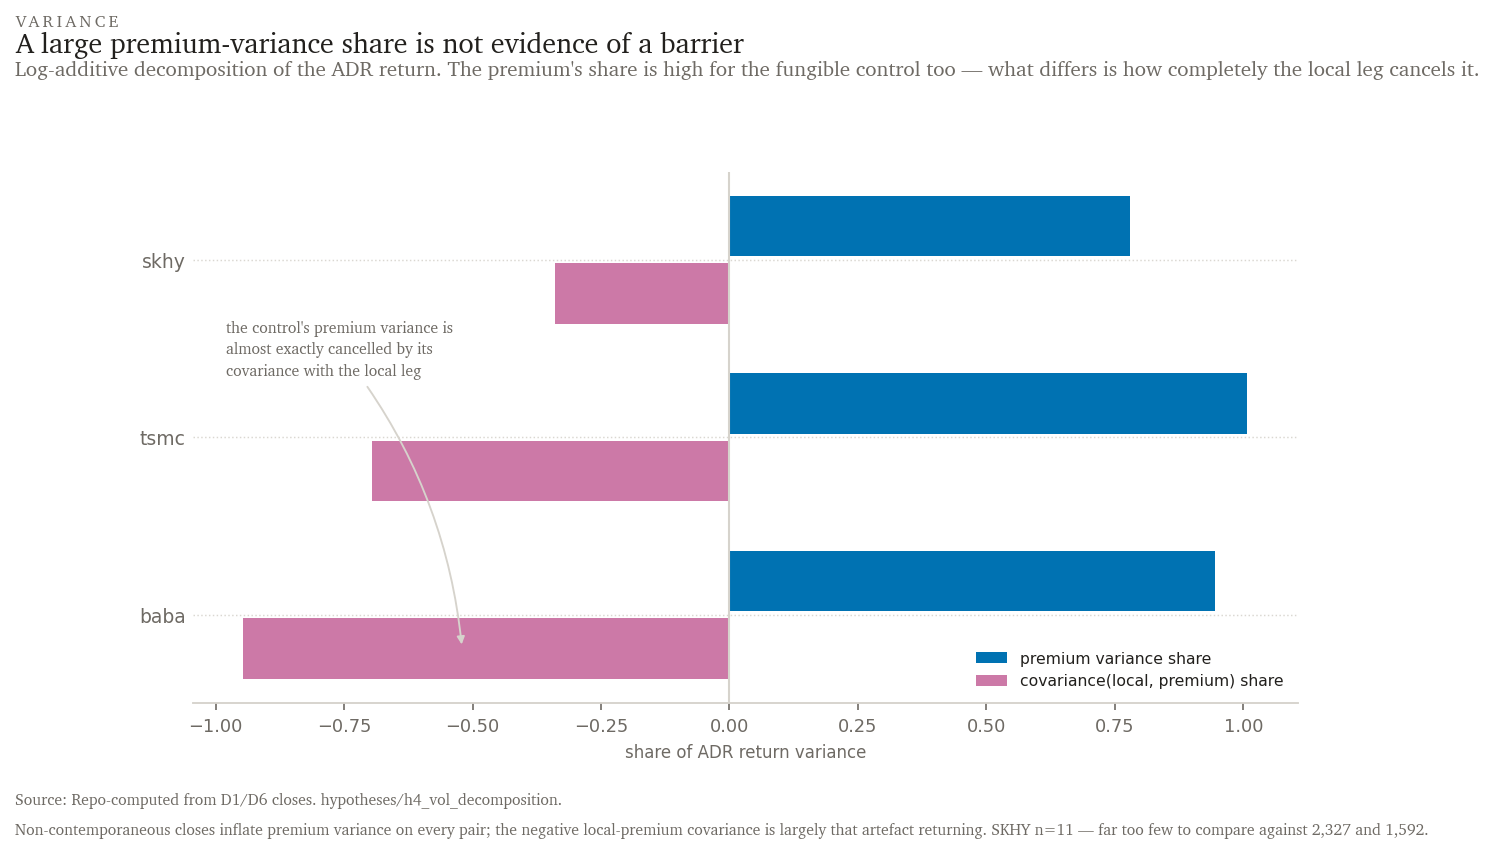

In [5]:
from hypotheses.h4_vol_decomposition.realized import compare_pairs
fig, ax = figures.g12_variance_shares(compare_pairs().to_dict("records"))
fig;

**In plain terms**

- Break the US share's daily moves into three parts: the Korean share, the currency, and the gap
  between them.
- The gap looks like most of the risk in every case — including the ones where the trade works
  both ways. So a big gap-share on its own proves nothing.
- The tell is that for a freely tradeable pair the gap almost exactly cancels against the local
  share: it opens and closes inside a day, mostly because the two markets close at different
  times.

**No regime-timeline figure, deliberately.** The session spec paired the variance figure with
one. There is nothing to plot: regime is a per-pair label read off a filing, so a timeline of
it is a horizontal line. The time-varying quantity is *binding-ness* — headroom — which the H5
monitor already reports as text, and which has a single observation on the capped programme.

## What this unlocks, and what it does not

The table's half-lives are what the trade sheets accrue financing against, and they are quoted
as a **floor with an open tail**: at least 220 trading days at 95%, no finite upper bound,
because ρ's upper confidence edge never crosses one half at any estimable horizon.

It does not unlock a point cost. Cost is linear in holding horizon and the horizon's upper
tail is open, so a point estimate would understate in the direction that flatters the trade.

Regenerate everything here with `just s4`. Research programme:
**[00 pitch](00_executive_pitch.ipynb)** · **[01 client note](01_client_note.ipynb)** ·
**[02 anatomy](02_premium_anatomy.ipynb)** · **[05 engines](05_hypothesis_engines.ipynb)**.